{'topic': '猫咪', 'poem': AIMessage(content='## 《猫》\n\n当我在月光下摊开\n记忆的毛线团，\n午后的光线便突然柔软。\n你走过的每一个窗台，\n花盆里的薄荷香，\n都会使你想起——\n那枚灰白的脚印，\n像一朵完整的梅花，\n突然开在蓝色的床单上。\n\n很轻，很轻，\n比黄昏的叹息更轻。\n当你用前爪丈量\n房间与房间的距离，\n毛茸茸的尾巴划破\n静止的空气时，\n厨房里传来牛奶煮沸的声音。\n\n此时，蜷伏是唯一合理的姿势。\n你的瞳孔渐渐调节成\n墙角的暗度。\n你藏起利爪，\n让肚皮的绒毛\n吸收地板的温度。\n在毛线团里，\n你听见了冬季的呼唤，\n就用呼噜声回应。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 10, 'total_tokens': 168, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 10}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '28925345-5c7c-40b5-851f-bbd0edaeb258', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f9d51-10dd-7372-900b-59f2c10c0944-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 158, 

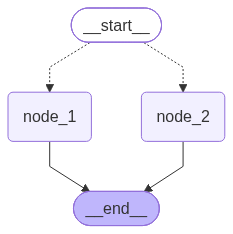

: 

In [ ]:
# -*- coding: utf-8 -*-
# 【CP2-02 条件路由】add_conditional_edges 的字面量分支
# 文件：CP2/02_route.ipynb
# 作用：本 Cell 演示 【CP2-02 条件路由】add_conditional_edges 的字面量分支 的完整可运行示例
# 阅读顺序：状态定义 → 节点定义 → 图构建 → 编译执行 → 结果观察

from dotenv import load_dotenv
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph,START,END    
from typing import TypedDict, Annotated,Literal
load_dotenv()

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={        
        "thinking":{
            "type":"disabled"
        }
    }
)

# 1 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

def node_1(state : OverAllState) -> OverAllState:
    # 向全局状态添加poem
    return {
        "poem": model.invoke(f"请写一首关于{state['topic']}的诗"),  # AND 汇合：需全部前驱完成才触发下游
    }

def node_2(state : OverAllState) -> OverAllState:
    # 向全局状态添加joke
    return {
        "joke": model.invoke(f"请写一个关于{state['topic']}的笑话"),  # AND 汇合：需全部前驱完成才触发下游
    }

# 添加路由
def my_route(state : OverAllState) -> Literal["node_1", "node_2"]:
    # 根据topic判断是否需要路由
    if "诗" in state["content_type"]:
        return "node_1"
    else:
        return "node_2"

# 2 构建状态图
builder = StateGraph(state_schema=OverAllState)  # 创建状态图构建器：绑定状态 Schema
builder.add_node("node_1", node_1)  # 注册节点到图中
builder.add_node("node_2", node_2)  # 注册节点到图中
builder.add_conditional_edges(START,my_route)  # 条件边：按函数返回值决定下一节点
builder.add_edge("node_1", END)  # 汇入终点
builder.add_edge("node_2", END)  # 汇入终点

graph = builder.compile()  # 编译图：蓝图→可执行对象

result1 = graph.invoke({"topic": "猫咪","content_type":"诗"})  # 触发图执行：传入初始 State + config
print(result1)

result2 = graph.invoke({"topic": "猫咪","content_type":"笑话"})  # 触发图执行：传入初始 State + config
print(result2)


from IPython.display import display
display(graph)
